# Animacion de evolucion diferencial sobre Rastrigin 2D

Este notebook reconstruye una corrida representativa de `evolucion diferencial` sobre `Rastrigin` en `2D`, dibuja la evolucion de la poblacion sobre un mapa de calor y guarda un `.gif` en la carpeta de figuras de heuristicas.

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
from IPython.display import Image as IPImage, display
from PIL import Image, ImageDraw

def find_project_dir(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "1. optimizacion_numerica" and (candidate / "functions").exists():
            return candidate
    raise FileNotFoundError("No se pudo ubicar la carpeta 1. optimizacion_numerica.")


ROOT_DIR = find_project_dir()
HEURISTICOS_DIR = ROOT_DIR / "heuristicos"
FUNCTIONS_DIR = ROOT_DIR / "functions"

if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

from funciones_objetivo import rastrigin
from funciones_heuristicas import run_differential_evolution

In [2]:
DATOS_DIR = HEURISTICOS_DIR / "datos"
FIGURAS_DIR = ROOT_DIR / "assets" / "animaciones"
FIGURAS_DIR.mkdir(parents=True, exist_ok=True)

RESULTADOS_PATH = DATOS_DIR / "rastrigin" / "rastrigin_de_2d_n1000.json"
with RESULTADOS_PATH.open("r", encoding="utf-8") as file:
    corridas_guardadas = json.load(file)

mejor_corrida = min(
    corridas_guardadas,
    key=lambda corrida: (float(corrida["mejor_valor"]), float(corrida["distancia_al_optimo"])),
)

CONFIG = {
    "dimension": 2,
    "lower_bounds": -5.12,
    "upper_bounds": 5.12,
    "population_size": int(mejor_corrida["parametros"]["population_size"]),
    "mutation_factor": float(mejor_corrida["parametros"]["mutation_factor"]),
    "crossover_rate": float(mejor_corrida["parametros"]["crossover_rate"]),
    "max_iterations": int(mejor_corrida["parametros"]["max_iterations"]),
    "seed": int(mejor_corrida["semilla"]),
    "frame_step": 3,
    "grid_points": 240,
    "canvas_width": 920,
    "canvas_height": 720,
    "padding": 70,
    "gif_name": f"animacion_de_rastrigin_2d_semilla_{int(mejor_corrida['semilla'])}.gif",
    "preview_name": f"preview_animacion_de_rastrigin_2d_semilla_{int(mejor_corrida['semilla'])}.png",
    "metadata_name": f"animacion_de_rastrigin_2d_semilla_{int(mejor_corrida['semilla'])}.json",
}

print("Archivo base:", RESULTADOS_PATH.resolve())
print("Corrida elegida:", mejor_corrida["corrida"])
print("Semilla elegida:", CONFIG["seed"])
print("Mejor valor registrado:", mejor_corrida["mejor_valor"])
CONFIG

NameError: name 'HEURISTICOS_DIR' is not defined

In [ ]:
resultado = run_differential_evolution(
    objective_function=rastrigin,
    population_size=CONFIG["population_size"],
    dimension=CONFIG["dimension"],
    lower_bounds=CONFIG["lower_bounds"],
    upper_bounds=CONFIG["upper_bounds"],
    mutation_factor=CONFIG["mutation_factor"],
    crossover_rate=CONFIG["crossover_rate"],
    max_iterations=CONFIG["max_iterations"],
    seed=CONFIG["seed"],
)

poblaciones = [np.array(pop, dtype=float) for pop in resultado["populations_history"]]
best_history = np.array(resultado["best_solutions_history"], dtype=float)
best_values = np.array(resultado["best_values_history"], dtype=float)

frame_indices = list(range(0, len(poblaciones), CONFIG["frame_step"]))
if frame_indices[-1] != len(poblaciones) - 1:
    frame_indices.append(len(poblaciones) - 1)

poblaciones_animadas = [poblaciones[index] for index in frame_indices]
best_history_animado = best_history[frame_indices]
best_values_animados = best_values[frame_indices]

print("Poblaciones totales:", len(poblaciones))
print("Frames animados:", len(poblaciones_animadas))
print("Mejor solucion reconstruida:", resultado["best_solution"])
print("Mejor valor reconstruido:", resultado["best_value"])
print("Evaluaciones reconstruidas:", resultado["evaluations"])

Poblaciones totales: 121
Frames animados: 41
Mejor solucion reconstruida: [-7.39209665e-10 -1.59929452e-10]
Mejor valor reconstruido: 0.0
Evaluaciones reconstruidas: 4840


In [ ]:
x = np.linspace(CONFIG["lower_bounds"], CONFIG["upper_bounds"], CONFIG["grid_points"])
y = np.linspace(CONFIG["lower_bounds"], CONFIG["upper_bounds"], CONFIG["grid_points"])
X, Y = np.meshgrid(x, y)
Z = 20 + X**2 + Y**2 - 10 * (np.cos(2 * np.pi * X) + np.cos(2 * np.pi * Y))
z_min = float(Z.min())
z_cap = float(np.percentile(Z, 98.5))
Z_clip = np.clip(Z, z_min, z_cap)
Z_norm = (Z_clip - z_min) / (z_cap - z_min)

def viridis_like_image(normalized_values: np.ndarray) -> Image.Image:
    v = np.asarray(normalized_values, dtype=float)
    r = np.clip(255 * (0.18 + 0.85 * np.power(v, 0.85)), 0, 255).astype(np.uint8)
    g = np.clip(255 * (0.10 + 0.95 * np.power(v, 0.55)), 0, 255).astype(np.uint8)
    b = np.clip(255 * (0.20 + 0.55 * (1.0 - np.power(v, 1.15))), 0, 255).astype(np.uint8)
    rgb = np.dstack([r, g, b])
    return Image.fromarray(rgb, mode="RGB")

BACKGROUND = viridis_like_image(Z_norm).resize(
    (
        CONFIG["canvas_width"] - 2 * CONFIG["padding"],
        CONFIG["canvas_height"] - 2 * CONFIG["padding"],
    ),
    resample=Image.Resampling.BILINEAR,
)

def to_pixel(point: np.ndarray) -> tuple[int, int]:
    width = CONFIG["canvas_width"] - 2 * CONFIG["padding"]
    height = CONFIG["canvas_height"] - 2 * CONFIG["padding"]
    x_min = CONFIG["lower_bounds"]
    x_max = CONFIG["upper_bounds"]
    y_min = CONFIG["lower_bounds"]
    y_max = CONFIG["upper_bounds"]

    px = CONFIG["padding"] + int((float(point[0]) - x_min) / (x_max - x_min) * width)
    py = CONFIG["padding"] + int((y_max - float(point[1])) / (y_max - y_min) * height)
    return px, py

def draw_axes(draw: ImageDraw.ImageDraw) -> None:
    left = CONFIG["padding"]
    top = CONFIG["padding"]
    right = CONFIG["canvas_width"] - CONFIG["padding"]
    bottom = CONFIG["canvas_height"] - CONFIG["padding"]

    draw.rectangle([left, top, right, bottom], outline=(240, 240, 240), width=2)

    for value in [-5.12, -2.56, 0.0, 2.56, 5.12]:
        px, py = to_pixel(np.array([value, value], dtype=float))
        draw.line([(px, top), (px, bottom)], fill=(255, 255, 255, 40), width=1)
        draw.line([(left, py), (right, py)], fill=(255, 255, 255, 40), width=1)
        draw.text((px - 14, bottom + 10), f"{value:.1f}", fill=(245, 245, 245))
        draw.text((left - 50, py - 7), f"{value:.1f}", fill=(245, 245, 245))

    draw.text((CONFIG["canvas_width"] // 2 - 95, 18), "Evolucion diferencial sobre Rastrigin 2D", fill=(250, 250, 250))
    draw.text((CONFIG["canvas_width"] // 2 - 18, CONFIG["canvas_height"] - 36), "x1", fill=(245, 245, 245))
    draw.text((18, CONFIG["canvas_height"] // 2), "x2", fill=(245, 245, 245))

def render_frame(frame: int) -> Image.Image:
    image = Image.new("RGB", (CONFIG["canvas_width"], CONFIG["canvas_height"]), (18, 22, 28))
    image.paste(BACKGROUND, (CONFIG["padding"], CONFIG["padding"]))
    draw = ImageDraw.Draw(image)
    draw_axes(draw)

    optimum = to_pixel(np.array([0.0, 0.0], dtype=float))
    draw.ellipse([optimum[0] - 6, optimum[1] - 6, optimum[0] + 6, optimum[1] + 6], fill=(255, 220, 0), outline=(0, 0, 0))

    trayectoria = [to_pixel(point) for point in best_history_animado[: frame + 1]]
    if len(trayectoria) >= 2:
        draw.line(trayectoria, fill=(220, 40, 60), width=3)

    for px, py in [to_pixel(point) for point in poblaciones_animadas[frame]]:
        draw.ellipse([px - 4, py - 4, px + 4, py + 4], fill=(0, 200, 255), outline=(0, 0, 0))

    best_px, best_py = to_pixel(best_history_animado[frame])
    draw.ellipse([best_px - 6, best_py - 6, best_px + 6, best_py + 6], fill=(255, 255, 255), outline=(0, 0, 0))

    paso_real = frame_indices[frame]
    info_lines = [
        f"Iteracion: {paso_real}",
        f"Mejor valor: {best_values_animados[frame]:.8f}",
        f"Mejor punto: ({best_history_animado[frame, 0]:.4f}, {best_history_animado[frame, 1]:.4f})",
        f"Semilla: {CONFIG['seed']}",
    ]
    box = [CONFIG["canvas_width"] - 330, 28, CONFIG["canvas_width"] - 26, 126]
    draw.rounded_rectangle(box, radius=12, fill=(255, 255, 255), outline=(40, 40, 40))
    for line_index, line in enumerate(info_lines):
        draw.text((box[0] + 14, box[1] + 12 + 22 * line_index), line, fill=(20, 20, 20))

    legend_box = [CONFIG["canvas_width"] - 330, 142, CONFIG["canvas_width"] - 26, 238]
    draw.rounded_rectangle(legend_box, radius=12, fill=(255, 255, 255), outline=(40, 40, 40))
    draw.ellipse([legend_box[0] + 14, legend_box[1] + 14, legend_box[0] + 26, legend_box[1] + 26], fill=(0, 200, 255), outline=(0, 0, 0))
    draw.text((legend_box[0] + 36, legend_box[1] + 12), "Poblacion", fill=(20, 20, 20))
    draw.line([(legend_box[0] + 14, legend_box[1] + 46), (legend_box[0] + 28, legend_box[1] + 46)], fill=(220, 40, 60), width=3)
    draw.text((legend_box[0] + 36, legend_box[1] + 38), "Mejor trayectoria", fill=(20, 20, 20))
    draw.ellipse([legend_box[0] + 14, legend_box[1] + 68, legend_box[0] + 26, legend_box[1] + 80], fill=(255, 220, 0), outline=(0, 0, 0))
    draw.text((legend_box[0] + 36, legend_box[1] + 64), "Minimo global", fill=(20, 20, 20))

    return image

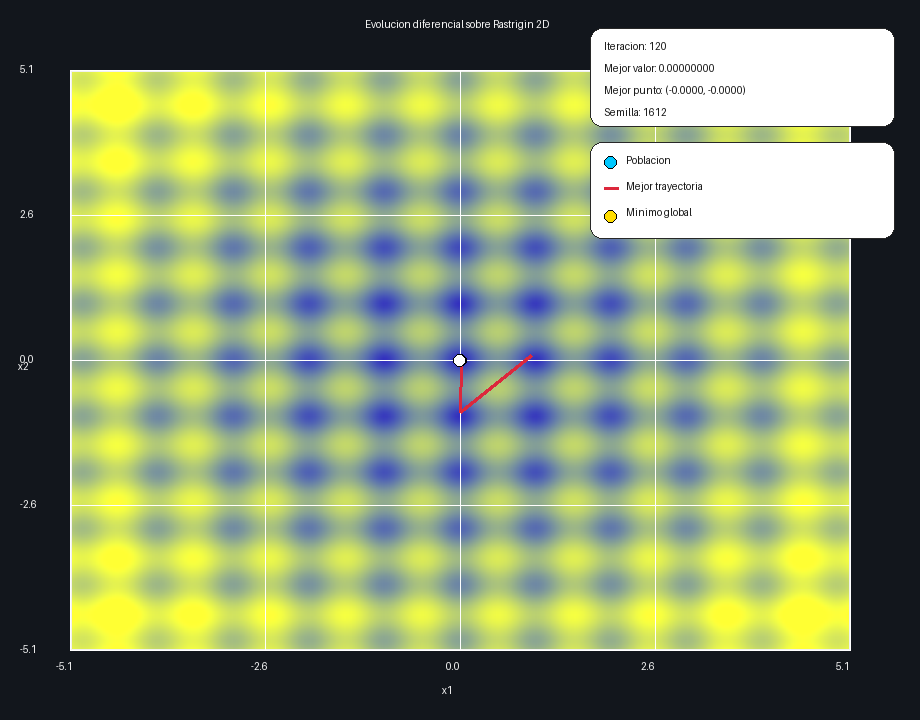

In [ ]:
preview_path = FIGURAS_DIR / CONFIG["preview_name"]
preview_image = render_frame(len(poblaciones_animadas) - 1)
preview_image.save(preview_path)
display(IPImage(filename=str(preview_path.resolve())))

In [ ]:
frames = [render_frame(frame) for frame in range(len(poblaciones_animadas))]
gif_path = FIGURAS_DIR / CONFIG["gif_name"]
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    duration=130,
    loop=0,
)

metadata = {
    "archivo_base": str(RESULTADOS_PATH.resolve()),
    "corrida_elegida": int(mejor_corrida["corrida"]),
    "semilla": int(CONFIG["seed"]),
    "population_size": int(CONFIG["population_size"]),
    "mutation_factor": float(CONFIG["mutation_factor"]),
    "crossover_rate": float(CONFIG["crossover_rate"]),
    "max_iterations": int(CONFIG["max_iterations"]),
    "best_value_reconstruido": float(resultado["best_value"]),
    "best_solution_reconstruida": [float(value) for value in resultado["best_solution"]],
    "evaluations": int(resultado["evaluations"]),
    "frames": int(len(frames)),
    "gif_path": str(gif_path.resolve()),
}

metadata_path = FIGURAS_DIR / CONFIG["metadata_name"]
metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")

print(f"Animacion guardada en: {gif_path.resolve()}")
print(f"Preview guardado en: {preview_path.resolve()}")
print(f"Metadata guardada en: {metadata_path.resolve()}")

Animacion guardada en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\animacion_de_rastrigin_2d_semilla_1612.gif
Preview guardado en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\preview_animacion_de_rastrigin_2d_semilla_1612.png
Metadata guardada en: C:\Carlos\Uni\Algortimos\trabajos\trabajo_1\trabajo_carlos\1. optimizacion_numerica\heuristicos\datos\figuras\animacion_de_rastrigin_2d_semilla_1612.json
